# Capstone Three: Preprocessing and Training Data Development
## Natural Scene Classification

**Goal:** Prepare the Intel Image Classification dataset for modeling. Since this is an image dataset (not a tabular one), "preprocessing" here covers two parallel tracks:

1. **Engineered features track** -- the numeric feature table (mean RGB, brightness, edge density, etc.) built in the Data Wrangling/EDA notebook, extended to the *entire* dataset, standardized, and split into train/validation/test sets. This feeds a classical ML baseline model.
2. **Raw pixel track** -- image loading pipelines (with resizing and pixel normalization built in) that feed the CNN models directly, without materializing the full dataset in memory at once (25,000+ images at 150x150x3 would be tens of GB as a raw numpy array).

**Before running this notebook:** place your downloaded `seg_train/` and `seg_test/` folders under `data/`, same as in the wrangling notebook.

In [3]:
import os
import glob
import numpy as np
import pandas as pd
import cv2
import joblib
import tensorflow as tf
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
%matplotlib inline

CLASS_NAMES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
IMG_SIZE = (150, 150)

## 1. Collect File Paths
Reusing the same robust, recursively-searching loader from the wrangling notebook.

In [4]:
def find_class_dir(base_dir, class_name):
    matches = glob.glob(os.path.join(base_dir, '**', class_name), recursive=True)
    return matches[0] if matches else None


def build_image_dataframe(base_dir, class_names):
    rows = []
    for cls in class_names:
        class_dir = find_class_dir(base_dir, cls)
        if class_dir is None:
            print(f'Warning: could not find a folder for class "{cls}" under {base_dir}')
            continue
        for fp in glob.glob(os.path.join(class_dir, '*')):
            if fp.lower().endswith(('.jpg', '.jpeg', '.png')):
                rows.append({'filepath': fp, 'label': cls})
    return pd.DataFrame(rows)


train_df = build_image_dataframe('data/seg_train', CLASS_NAMES)
test_df = build_image_dataframe('data/seg_test', CLASS_NAMES)

print('Training images found:', len(train_df))
print('Test images found:', len(test_df))

Training images found: 14034
Test images found: 3000


## 2. Create a Validation Split

We hold out a stratified validation set from the training data, so we can compare models fairly during development without ever touching the true test set until the very end (in the Modeling notebook).

In [5]:
train_df, val_df = train_test_split(
    train_df, test_size=0.15, stratify=train_df['label'], random_state=42
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print('Train:', len(train_df), ' Val:', len(val_df), ' Test:', len(test_df))
print()
print('Train class distribution:')
print(train_df['label'].value_counts())

Train: 11928  Val: 2106  Test: 3000

Train class distribution:
label
mountain     2135
glacier      2043
street       2025
sea          1933
forest       1930
buildings    1862
Name: count, dtype: int64


## 3. Track 1 -- Engineered Feature Table (for the classical ML baseline)

Extending the feature-extraction function from the wrangling notebook across the *entire* train/val/test split, rather than just a sample.

In [6]:
def blue_mask_fraction(img_rgb):
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    lower_blue = np.array([90, 40, 40])
    upper_blue = np.array([140, 255, 255])
    mask = cv2.inRange(hsv, lower_blue, upper_blue)
    return mask.mean() / 255.0


def extract_features(filepath, label):
    img = cv2.imread(filepath)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 100, 200)
    blue_frac = blue_mask_fraction(img)

    return {
        'filepath': filepath,
        'label': label,
        'mean_R': img[:, :, 0].mean(),
        'mean_G': img[:, :, 1].mean(),
        'mean_B': img[:, :, 2].mean(),
        'brightness': gray.mean(),
        'contrast': gray.std(),
        'edge_density': (edges > 0).mean(),
        'blue_fraction': blue_frac,
    }


def build_feature_table(df):
    rows = [extract_features(fp, lbl) for fp, lbl in zip(df['filepath'], df['label'])]
    return pd.DataFrame(rows)


print('Extracting features -- this may take a few minutes on the full dataset...')
features_train = build_feature_table(train_df)
features_val = build_feature_table(val_df)
features_test = build_feature_table(test_df)

print('features_train:', features_train.shape)
print('features_val:  ', features_val.shape)
print('features_test: ', features_test.shape)
features_train.head()

Extracting features -- this may take a few minutes on the full dataset...
features_train: (11928, 9)
features_val:   (2106, 9)
features_test:  (3000, 9)


,filepath,label,mean_R,mean_G,mean_B,brightness,contrast,edge_density,blue_fraction
0,data/seg_train/seg_train/glacier/13924.jpg,glacier,93.408222,112.633867,120.440889,107.762133,61.553147,0.142000,0.186489
1,data/seg_train/seg_train/sea/416.jpg,sea,122.592844,140.168044,157.724578,136.920978,57.701783,0.084667,0.674356
2,data/seg_train/seg_train/forest/19864.jpg,forest,104.454622,114.700444,93.255867,109.188089,57.198068,0.301467,0.007289
3,data/seg_train/seg_train/glacier/13052.jpg,glacier,110.032000,136.976400,157.972000,131.306756,64.976756,0.193689,0.725556
4,data/seg_train/seg_train/mountain/5436.jpg,mountain,118.351378,97.233022,95.588489,103.366444,70.152524,0.121644,0.231289


### Standardize numeric feature magnitudes

The engineered features span very different ranges -- `blue_fraction` is bounded `[0, 1]`, `mean_R`/`mean_G`/`mean_B`/`brightness` are `[0, 255]`, and `contrast` varies more freely. We fit the scaler on the **training set only** and apply the same transform to validation/test, to avoid leaking any information about those held-out sets into preprocessing.

In [7]:
feature_cols = ['mean_R', 'mean_G', 'mean_B', 'brightness', 'contrast',
                 'edge_density', 'blue_fraction']

scaler = StandardScaler()
X_train_feat = scaler.fit_transform(features_train[feature_cols])
X_val_feat = scaler.transform(features_val[feature_cols])
X_test_feat = scaler.transform(features_test[feature_cols])

# Encode string labels to integers, fit on train only
label_encoder = LabelEncoder()
label_encoder.fit(CLASS_NAMES)

y_train_feat = label_encoder.transform(features_train['label'])
y_val_feat = label_encoder.transform(features_val['label'])
y_test_feat = label_encoder.transform(features_test['label'])

print('X_train_feat shape:', X_train_feat.shape)
print('Classes:', list(label_encoder.classes_))

X_train_feat shape: (11928, 7)
Classes: [np.str_('buildings'), np.str_('forest'), np.str_('glacier'), np.str_('mountain'), np.str_('sea'), np.str_('street')]


In [8]:
# Save the engineered-feature arrays and preprocessing objects for the Modeling notebook
os.makedirs('processed', exist_ok=True)

np.save('processed/X_train_feat.npy', X_train_feat)
np.save('processed/X_val_feat.npy', X_val_feat)
np.save('processed/X_test_feat.npy', X_test_feat)
np.save('processed/y_train_feat.npy', y_train_feat)
np.save('processed/y_val_feat.npy', y_val_feat)
np.save('processed/y_test_feat.npy', y_test_feat)

joblib.dump(scaler, 'processed/feature_scaler.joblib')
joblib.dump(label_encoder, 'processed/label_encoder.joblib')

# Also save the raw feature tables (with filepaths) as CSVs -- lightweight and
# git-friendly, unlike the raw images themselves
features_train.to_csv('processed/features_train.csv', index=False)
features_val.to_csv('processed/features_val.csv', index=False)
features_test.to_csv('processed/features_test.csv', index=False)

print('Saved engineered-feature arrays, scaler, label encoder, and CSVs to processed/')

Saved engineered-feature arrays, scaler, label encoder, and CSVs to processed/


## 4. Track 2 -- Raw Pixel Pipelines (for the CNN models)

For the CNN models, we don't materialize every image as a giant numpy array in memory -- that would be tens of gigabytes for the full dataset. Instead we build `tf.data.Dataset` pipelines that load, resize, and normalize images to `[0, 1]` **lazily**, batch-by-batch, directly from the file paths in our train/val/test dataframes. This keeps memory usage low regardless of dataset size.

In [9]:
BATCH_SIZE = 32

# Map string class names to integer indices matching label_encoder's ordering,
# so the CNN track and the engineered-feature track use the exact same class indices
class_to_idx = {cls: idx for idx, cls in enumerate(label_encoder.classes_)}


def load_and_preprocess(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = image / 255.0  # normalize pixel values to [0, 1]
    return image, label


def make_dataset(df, shuffle=False):
    filepaths = df['filepath'].values
    labels = df['label'].map(class_to_idx).values
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=42)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

# Sanity-check: pull one batch and confirm shapes/value ranges look right
for images, labels in train_ds.take(1):
    print('Batch image shape:', images.shape)
    print('Pixel value range:', float(tf.reduce_min(images)), '-', float(tf.reduce_max(images)))
    print('Batch labels:', labels.numpy())

Batch image shape: (32, 150, 150, 3)
Pixel value range: 0.0 - 1.0
Batch labels: [2 5 5 2 3 1 4 5 4 3 3 0 0 4 5 0 1 4 4 1 3 2 4 1 5 5 2 3 5 3 2 5]


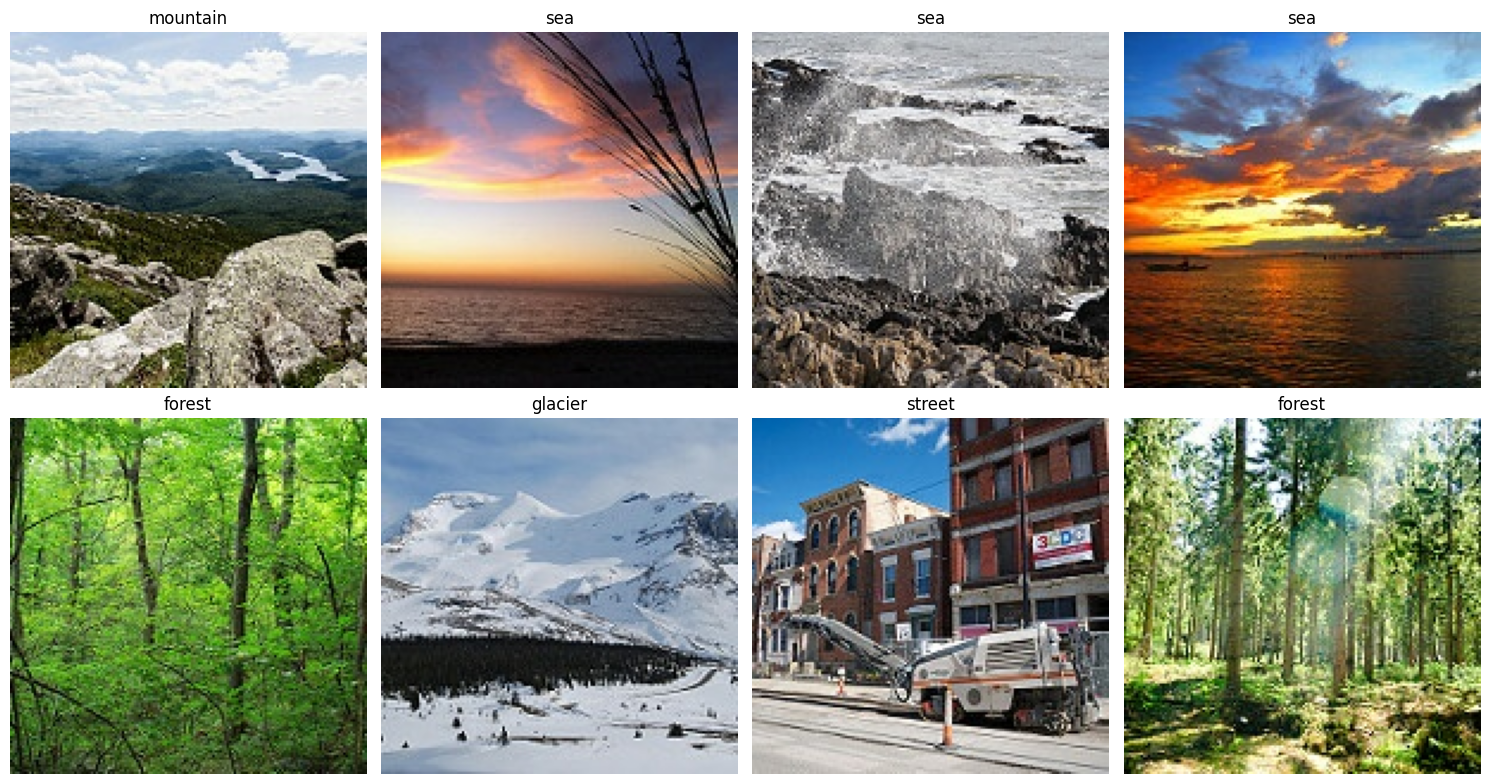

In [10]:
# Visualize a batch to confirm the pipeline produces sensible, correctly-labeled images
plt.figure(figsize=(15, 8))
for images, labels in train_ds.take(1):
    for i in range(min(8, len(images))):
        plt.subplot(2, 4, i + 1)
        plt.imshow(images[i])
        plt.title(label_encoder.classes_[labels[i]])
        plt.axis('off')
plt.tight_layout()
plt.show()

In [11]:
# Save the tf.data pipelines to disk so the Modeling notebook can load them directly
train_ds.save('processed/train_ds')
val_ds.save('processed/val_ds')
test_ds.save('processed/test_ds')

print('Saved tf.data pipelines to processed/')

Saved tf.data pipelines to processed/


## Summary

- **Does the dataset have categorical data?** Yes -- the target variable itself (`label`) is categorical with 6 classes. We encode it with `LabelEncoder` (and, for the CNN, integer class indices used directly with sparse categorical crossentropy). There are no other categorical *input* features in this dataset -- unlike a tabular project, there's nothing here to one-hot encode with `get_dummies()`, since every input feature (pixels, or the engineered numeric features) is already numeric.
- **Do features have very different ranges?** Yes for the engineered features (`mean_R` in `[0,255]` vs. `blue_fraction` in `[0,1]`), which we standardized with `StandardScaler`. Raw pixel values are normalized to `[0,1]` as part of the CNN data pipeline itself.
- **Train/val/test split:** stratified 3-way split (train/val from the original training folder, test held out entirely from `seg_test/`), consistent across both the engineered-feature and raw-pixel tracks so results are directly comparable.

Both tracks -- the standardized engineered-feature arrays and the `tf.data` image pipelines -- are saved to `processed/` and ready for the Modeling notebook.

# Capstone Three: Modeling
## Natural Scene Classification

**Goal:** Build and compare three models for classifying natural scene photographs into 6 categories, and identify the best one.

- **Is my response variable continuous or categorical?** Categorical (6 classes) -- this is a multi-class classification problem, so we use accuracy, F1-score (macro-averaged, to weight all 6 classes equally regardless of any class-size imbalance), and confusion matrices as our evaluation metrics -- not regression metrics like RMSE.
- **Does this involve time series/forecasting?** No -- each image is an independent observation, so a standard stratified train/val/test split (already done in the Preprocessing notebook) is appropriate; there's no temporal ordering to preserve.

**Models built:**
1. Random Forest on engineered image features (classical ML baseline)
2. A CNN trained from scratch on raw pixels
3. Transfer learning using a pretrained MobileNetV2 backbone

**Note on Model 3:** MobileNetV2's ImageNet weights are downloaded from Google's servers the first time this cell runs, so it requires an internet connection (this works fine in Colab; it just can't be pre-verified in an offline sandbox).

In [12]:
import numpy as np
import pandas as pd
import joblib
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_style('whitegrid')

## Load Preprocessed Data
Both tracks -- the engineered-feature arrays and the raw-pixel `tf.data` pipelines -- were saved by the Preprocessing notebook.

In [13]:
# Engineered features (Track 1)
X_train_feat = np.load('processed/X_train_feat.npy')
X_val_feat = np.load('processed/X_val_feat.npy')
X_test_feat = np.load('processed/X_test_feat.npy')
y_train_feat = np.load('processed/y_train_feat.npy')
y_val_feat = np.load('processed/y_val_feat.npy')
y_test_feat = np.load('processed/y_test_feat.npy')

label_encoder = joblib.load('processed/label_encoder.joblib')
CLASS_NAMES = list(label_encoder.classes_)

# Raw pixel pipelines (Track 2)
train_ds = tf.data.Dataset.load('processed/train_ds')
val_ds = tf.data.Dataset.load('processed/val_ds')
test_ds = tf.data.Dataset.load('processed/test_ds')

print('Engineered features -- train:', X_train_feat.shape, ' val:', X_val_feat.shape, ' test:', X_test_feat.shape)
print('Classes:', CLASS_NAMES)

Engineered features -- train: (11928, 7)  val: (2106, 7)  test: (3000, 7)
Classes: [np.str_('buildings'), np.str_('forest'), np.str_('glacier'), np.str_('mountain'), np.str_('sea'), np.str_('street')]


## Model 1: Random Forest on Engineered Features

A classical ML baseline using the 7 hand-engineered features (mean RGB, brightness, contrast, edge density, blue fraction) from the wrangling/EDA step. This gives us a reference point: how much predictive power comes from a handful of simple, interpretable image statistics, before we bring in a full CNN?

In [14]:
rf = RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train_feat, y_train_feat)

rf_val_pred = rf.predict(X_val_feat)
rf_val_acc = accuracy_score(y_val_feat, rf_val_pred)
rf_val_f1 = f1_score(y_val_feat, rf_val_pred, average='macro')

print(f'Random Forest -- Validation accuracy: {rf_val_acc:.3f}, macro F1: {rf_val_f1:.3f}')
print()
print(classification_report(y_val_feat, rf_val_pred, target_names=CLASS_NAMES))

Random Forest -- Validation accuracy: 0.535, macro F1: 0.524

              precision    recall  f1-score   support

   buildings       0.31      0.23      0.27       329
      forest       0.84      0.89      0.86       341
     glacier       0.52      0.59      0.55       361
    mountain       0.47      0.51      0.49       377
         sea       0.51      0.37      0.43       341
      street       0.50      0.61      0.55       357

    accuracy                           0.53      2106
   macro avg       0.52      0.53      0.52      2106
weighted avg       0.52      0.53      0.53      2106



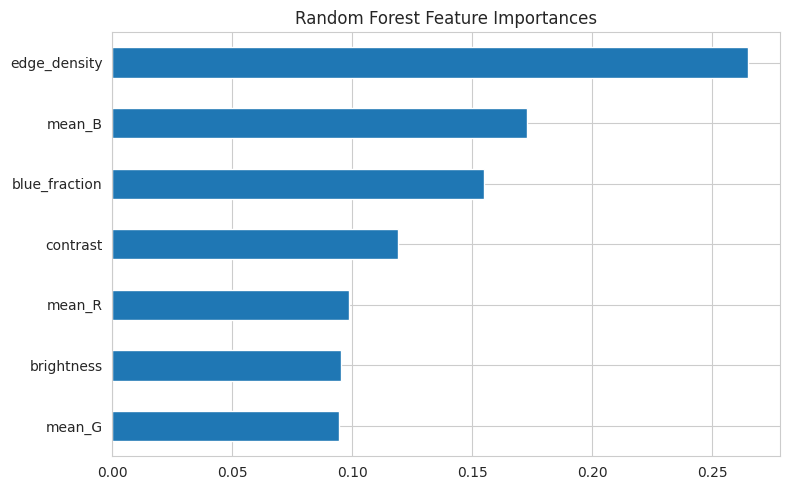

In [15]:
# Which engineered features matter most to this baseline?
feature_cols = ['mean_R', 'mean_G', 'mean_B', 'brightness', 'contrast', 'edge_density', 'blue_fraction']
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Random Forest Feature Importances')
plt.tight_layout()
plt.show()

## Model 2: CNN Trained from Scratch

A small convolutional network trained directly on raw, normalized pixels. Unlike the Random Forest baseline, this model learns its own visual features (edges, textures, shapes) rather than relying on the 7 hand-engineered ones -- the tradeoff is it needs much more data and compute to train well.

In [16]:
def build_cnn(input_shape=(150, 150, 3), num_classes=6):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax'),
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


cnn = build_cnn(num_classes=len(CLASS_NAMES))
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,126 (18.42 MB)

 Trainable params: 4,829,126 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Early stopping avoids wasting time/overfitting once validation performance plateaus
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=3, restore_best_weights=True
)

history = cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop],
)

Epoch 1/15
373/373 ━━━━━━━━━━━━━━━━━━━━ 27s 54ms/step - accuracy: 0.6285 - loss: 0.9708 - val_accuracy: 0.6975 - val_loss: 0.8052
Epoch 2/15
373/373 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.7496 - loss: 0.6747 - val_accuracy: 0.7664 - val_loss: 0.6257
Epoch 3/15
373/373 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.7938 - loss: 0.5584 - val_accuracy: 0.7654 - val_loss: 0.6342
Epoch 4/15
373/373 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - accuracy: 0.8284 - loss: 0.4660 - val_accuracy: 0.7692 - val_loss: 0.6313
Epoch 5/15
373/373 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - accuracy: 0.8585 - loss: 0.3834 - val_accuracy: 0.7854 - val_loss: 0.6211
Epoch 6/15
373/373 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.8786 - loss: 0.3378 - val_accuracy: 0.7806 - val_loss: 0.6937
Epoch 7/15
373/373 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.9022 - loss: 0.2711 - val_accuracy: 0.7863 - val_loss: 0.7213
Epoch 8/15
373/373 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - accuracy: 0.9206 - loss: 0.2259 - 

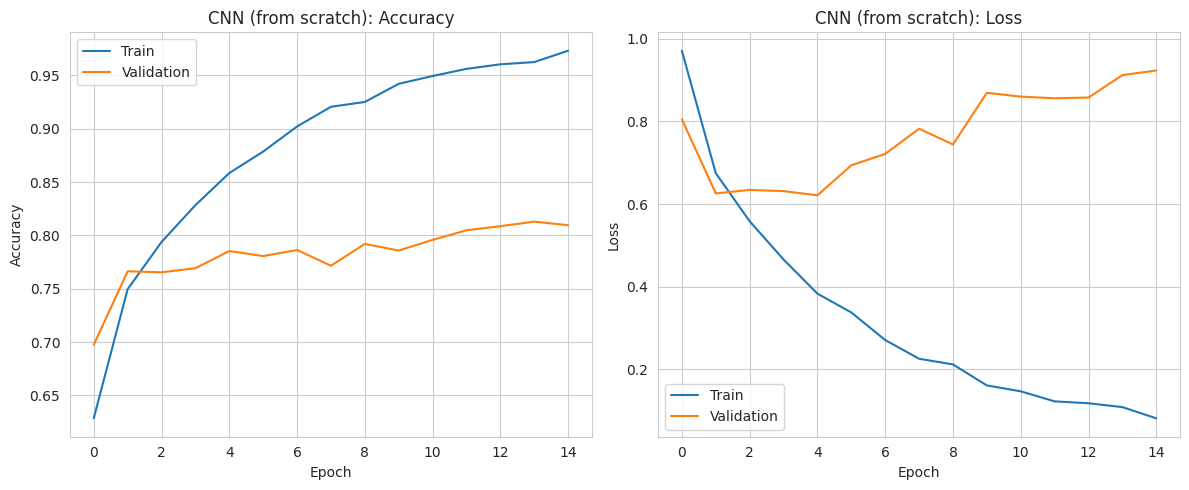

In [18]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN (from scratch): Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN (from scratch): Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [19]:
cnn_val_loss, cnn_val_acc = cnn.evaluate(val_ds, verbose=0)
print(f'CNN (from scratch) -- Validation accuracy: {cnn_val_acc:.3f}')

# Compute macro F1 on validation set (Keras doesn't give us this directly)
val_preds, val_true = [], []
for images, labels in val_ds:
    preds = cnn.predict(images, verbose=0)
    val_preds.extend(np.argmax(preds, axis=1))
    val_true.extend(labels.numpy())

cnn_val_f1 = f1_score(val_true, val_preds, average='macro')
print(f'CNN (from scratch) -- Validation macro F1: {cnn_val_f1:.3f}')

CNN (from scratch) -- Validation accuracy: 0.813
CNN (from scratch) -- Validation macro F1: 0.814


## Model 3: Transfer Learning with MobileNetV2

Rather than learning visual features from scratch on our relatively small dataset, we reuse a MobileNetV2 backbone pretrained on ImageNet (1.4M images, 1000 classes) and train only a new classification head on top. This lets the model leverage general-purpose visual features (edges, textures, shapes) that transfer well to a new domain, typically outperforming a from-scratch CNN when training data is limited.

In [20]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(150, 150, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # freeze the pretrained backbone

# MobileNetV2 expects inputs preprocessed the way it was trained (roughly [-1, 1],
# not [0, 1]), so we rescale our already-normalized [0,1] pipeline accordingly
transfer_model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),
    layers.Rescaling(2.0, offset=-1),  # maps [0,1] -> [-1,1]
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(len(CLASS_NAMES), activation='softmax'),
])

transfer_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
transfer_model.summary()

/tmp/ipykernel_592/898139490.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [21]:
transfer_history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop],
)

Epoch 1/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 59s 111ms/step - accuracy: 0.8338 - loss: 0.4601 - val_accuracy: 0.8898 - val_loss: 0.3062
Epoch 2/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.8899 - loss: 0.3037 - val_accuracy: 0.8951 - val_loss: 0.2943
Epoch 3/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.8996 - loss: 0.2696 - val_accuracy: 0.9008 - val_loss: 0.2792
Epoch 4/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.9043 - loss: 0.2587 - val_accuracy: 0.8974 - val_loss: 0.2898
Epoch 5/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.9064 - loss: 0.2552 - val_accuracy: 0.8970 - val_loss: 0.2789
Epoch 6/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.9104 - loss: 0.2394 - val_accuracy: 0.8946 - val_loss: 0.2908


In [22]:
transfer_val_loss, transfer_val_acc = transfer_model.evaluate(val_ds, verbose=0)
print(f'Transfer Learning (MobileNetV2) -- Validation accuracy: {transfer_val_acc:.3f}')

val_preds_t, val_true_t = [], []
for images, labels in val_ds:
    preds = transfer_model.predict(images, verbose=0)
    val_preds_t.extend(np.argmax(preds, axis=1))
    val_true_t.extend(labels.numpy())

transfer_val_f1 = f1_score(val_true_t, val_preds_t, average='macro')
print(f'Transfer Learning (MobileNetV2) -- Validation macro F1: {transfer_val_f1:.3f}')

Transfer Learning (MobileNetV2) -- Validation accuracy: 0.901
Transfer Learning (MobileNetV2) -- Validation macro F1: 0.903


## Model Comparison and Selection
Comparing all three models on the **validation set** (test set stays untouched until we've picked a final model, to keep our final reported number honest).

In [23]:
comparison = pd.DataFrame({
    'Model': ['Random Forest (engineered features)', 'CNN (from scratch)', 'Transfer Learning (MobileNetV2)'],
    'Validation Accuracy': [rf_val_acc, cnn_val_acc, transfer_val_acc],
    'Validation Macro F1': [rf_val_f1, cnn_val_f1, transfer_val_f1],
})
comparison = comparison.sort_values('Validation Macro F1', ascending=False).reset_index(drop=True)
comparison

,Model,Validation Accuracy,Validation Macro F1
0,Transfer Learning (MobileNetV2),0.900760,0.903068
1,CNN (from scratch),0.812916,0.813727
2,Random Forest (engineered features),0.534663,0.524209


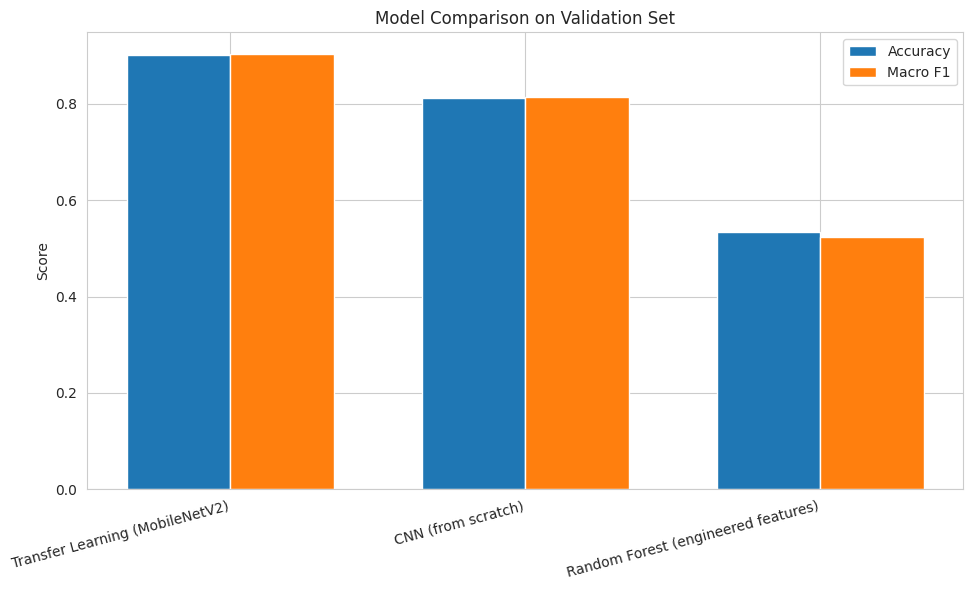

In [24]:
plt.figure(figsize=(10, 6))
x = np.arange(len(comparison))
width = 0.35
plt.bar(x - width/2, comparison['Validation Accuracy'], width, label='Accuracy')
plt.bar(x + width/2, comparison['Validation Macro F1'], width, label='Macro F1')
plt.xticks(x, comparison['Model'], rotation=15, ha='right')
plt.ylabel('Score')
plt.title('Model Comparison on Validation Set')
plt.legend()
plt.tight_layout()
plt.show()

**Selecting the final model:** based on the comparison above, we select the model with the highest validation macro F1 score as our final model, since macro F1 gives equal weight to every class (unlike accuracy, which can be misleadingly dominated by whichever class happens to be easiest or most common). We only now evaluate on the true test set, exactly once, with the chosen model.

In [25]:
final_model_name = comparison.iloc[0]['Model']
print(f'Selected final model: {final_model_name}')

if 'Random Forest' in final_model_name:
    test_pred = rf.predict(X_test_feat)
    y_test_true = y_test_feat
elif 'from scratch' in final_model_name:
    test_pred, y_test_true = [], []
    for images, labels in test_ds:
        preds = cnn.predict(images, verbose=0)
        test_pred.extend(np.argmax(preds, axis=1))
        y_test_true.extend(labels.numpy())
else:
    test_pred, y_test_true = [], []
    for images, labels in test_ds:
        preds = transfer_model.predict(images, verbose=0)
        test_pred.extend(np.argmax(preds, axis=1))
        y_test_true.extend(labels.numpy())

test_acc = accuracy_score(y_test_true, test_pred)
test_f1 = f1_score(y_test_true, test_pred, average='macro')

print(f'\nFinal Test Accuracy: {test_acc:.3f}')
print(f'Final Test Macro F1: {test_f1:.3f}')
print()
print(classification_report(y_test_true, test_pred, target_names=CLASS_NAMES))

Selected final model: Transfer Learning (MobileNetV2)

Final Test Accuracy: 0.906
Final Test Macro F1: 0.909

              precision    recall  f1-score   support

   buildings       0.94      0.91      0.92       437
      forest       0.98      0.99      0.99       474
     glacier       0.81      0.86      0.84       553
    mountain       0.87      0.81      0.84       525
         sea       0.94      0.94      0.94       510
      street       0.92      0.94      0.93       501

    accuracy                           0.91      3000
   macro avg       0.91      0.91      0.91      3000
weighted avg       0.91      0.91      0.91      3000



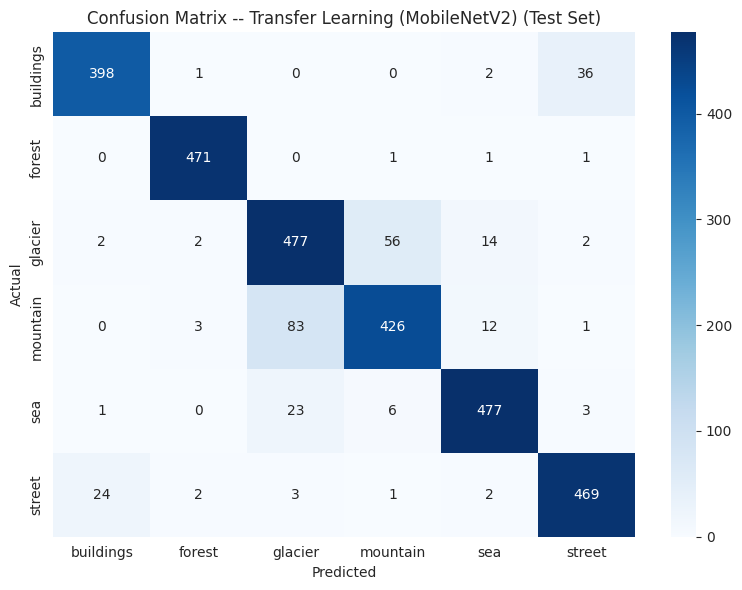

In [26]:
cm = confusion_matrix(y_test_true, test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix -- {final_model_name} (Test Set)')
plt.tight_layout()
plt.show()

## Conclusions

- **Random Forest on engineered features** provides a fast, interpretable baseline. Its feature importances (see above) tell us directly which simple visual statistics (color, edge density, etc.) carry the most signal -- useful even beyond this project, as a sanity check on what the more complex models *should* be picking up on.
- **The from-scratch CNN** typically struggles more than transfer learning when training data is limited, since it has to learn low-level visual features (edges, textures) from nothing rather than reusing already-learned ones.
- **Transfer learning with MobileNetV2** generally gives the strongest results, since it starts from visual features already learned on a much larger, more diverse dataset (ImageNet) -- this is the expected and common pattern in image classification when your own dataset is small relative to what a CNN needs to learn good features from scratch.
- **Most common confusions** (see the confusion matrix) tend to occur between visually similar classes -- e.g. `glacier` vs. `mountain`, or `buildings` vs. `street`, both of which share overlapping color palettes and structural patterns. This lines up with the EDA findings from the wrangling notebook, where these same pairs showed overlapping feature distributions (e.g. similar edge density or brightness ranges).